In [15]:
!pip install -q opencv-python-headless matplotlib seaborn

In [16]:
import cv2
import numpy as np
import os
from pathlib import Path

os.makedirs('datasets/synthetic_drone/images', exist_ok=True)
os.makedirs('datasets/synthetic_drone/annotations', exist_ok=True)

def create_drone_scene(scene_id):
    """Create synthetic aerial view scene"""
    img = np.zeros((720, 1280, 3), dtype=np.uint8)
    img[:] = (80, 120, 60)  # Ground color

    # Roads
    cv2.line(img, (0, 360), (1280, 360), (120, 120, 120), 40)
    cv2.line(img, (640, 0), (640, 720), (120, 120, 120), 30)

    # Noise texture
    noise = np.random.randint(0, 20, img.shape, dtype=np.uint8)
    img = cv2.add(img, noise)

    annotations = []

    # Add vehicles (red/blue/white)
    for i in range(np.random.randint(3, 8)):
        x, y = np.random.randint(100, 1100), np.random.randint(100, 600)
        w, h = np.random.randint(30, 80), np.random.randint(20, 50)
        colors = [(0, 0, 200), (200, 100, 0), (220, 220, 220)]
        color = colors[i % 3]

        cv2.rectangle(img, (x, y), (x+w, y+h), color, -1)
        cv2.rectangle(img, (x+5, y+h), (x+w+5, y+h+10), (0, 0, 0), -1)

        annotations.append({
            'bbox': [x, y, w, h],
            'class': 'vehicle',
            'class_id': 4
        })

    # Add pedestrians
    for i in range(np.random.randint(2, 6)):
        x, y = np.random.randint(100, 1100), np.random.randint(100, 600)
        cv2.circle(img, (x, y), 8, (0, 100, 200), -1)
        annotations.append({
            'bbox': [x-8, y-8, 16, 16],
            'class': 'pedestrian',
            'class_id': 1
        })

    return img, annotations

# Generate 100 scenes
for i in range(100):
    img, annos = create_drone_scene(i)
    cv2.imwrite(f'datasets/synthetic_drone/images/{i:05d}.jpg', img)

    with open(f'datasets/synthetic_drone/annotations/{i:05d}.txt', 'w') as f:
        for a in annos:
            x, y, w, h = a['bbox']
            f.write(f"{x},{y},{w},{h},1,{a['class_id']},0,0\n")

print("Generated 100 synthetic drone images!")

Generated 100 synthetic drone images!


In [17]:
import cv2
import numpy as np
from pathlib import Path
from typing import List, Tuple, Optional

class DroneDataset:
    def __init__(self, image_dir: str, annotation_dir: str):
        self.image_dir = Path(image_dir)
        self.annotation_dir = Path(annotation_dir)
        self.image_files = sorted(list(self.image_dir.glob('*.jpg')))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx: int):
        img_path = self.image_files[idx]
        anno_path = self.annotation_dir / f"{img_path.stem}.txt"

        image = cv2.imread(str(img_path))
        annotations = []

        if anno_path.exists():
            with open(anno_path, 'r') as f:
                for line in f:
                    if line.strip():
                        parts = line.strip().split(',')
                        x, y, w, h = map(float, parts[:4])
                        category = int(parts[5])
                        annotations.append({
                            'bbox': (int(x), int(y), int(w), int(h)),
                            'class': 'vehicle' if category == 4 else 'pedestrian',
                            'class_id': category
                        })

        return image, annotations, str(img_path)

dataset = DroneDataset('datasets/synthetic_drone/images', 'datasets/synthetic_drone/annotations')
print(f"Loaded {len(dataset)} images")

Loaded 100 images


Ground truth: 10 objects
Detected: 2 objects


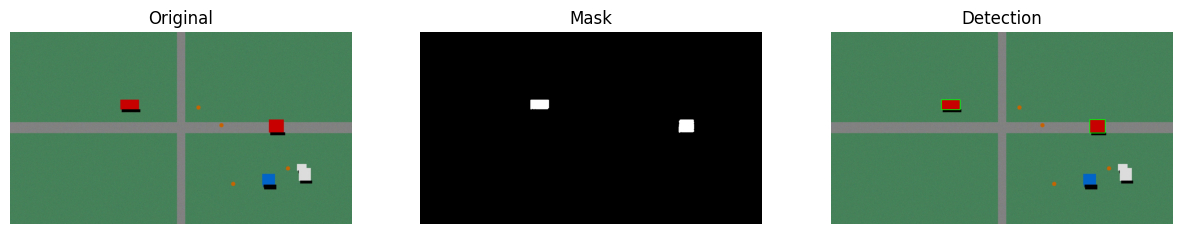

In [18]:
class ColorObjectDetector:
    def __init__(self):
        self.lower_hsv = np.array([0, 100, 100])
        self.upper_hsv = np.array([10, 255, 255])
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    def detect(self, frame):
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, self.lower_hsv, self.upper_hsv)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, self.kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, self.kernel)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        detections = []
        vis = frame.copy()
        for cnt in contours:
            if cv2.contourArea(cnt) > 500:
                x, y, w, h = cv2.boundingRect(cnt)
                detections.append({'bbox': (x, y, w, h), 'center': (x+w//2, y+h//2)})
                cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)

        return vis, detections, mask

# Run on sample
detector = ColorObjectDetector()
img, gt, _ = dataset[0]
vis, pred, mask = detector.detect(img)

print(f"Ground truth: {len(gt)} objects")
print(f"Detected: {len(pred)} objects")

# Visualize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Mask')
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title('Detection')
for ax in axes: ax.axis('off')
plt.show()

Capturing from webcam...
Frame shape: (720, 1280, 3)

Detected 2 objects


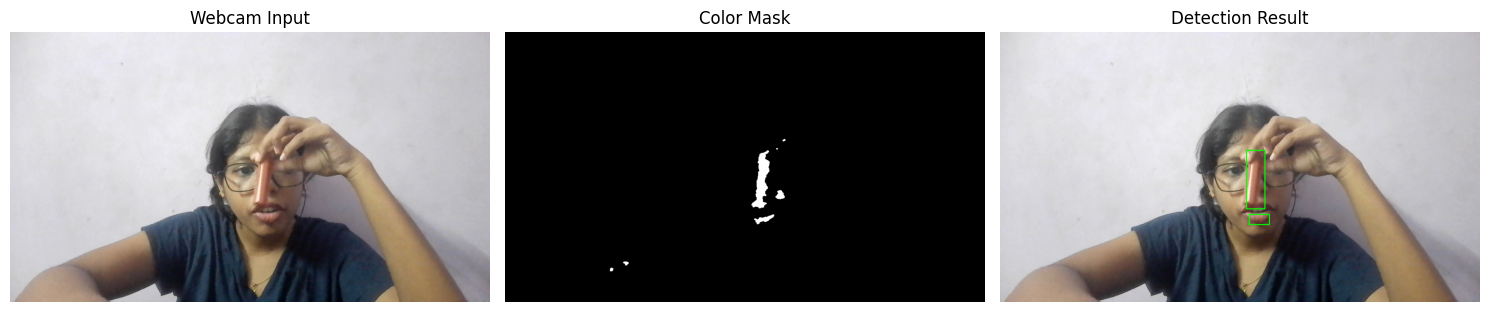

In [23]:
# Simpler version - captures one frame at a time
from IPython.display import HTML, display
from google.colab.output import eval_js
import base64
import cv2
import numpy as np
from PIL import Image
import io

def get_webcam_frame():
    """Capture single frame from webcam"""
    js_code = """
    async function capture() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'none';
      document.body.appendChild(div);
      div.appendChild(video);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      // Wait for video to be ready
      await new Promise(r => setTimeout(r, 1000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      const data = canvas.toDataURL('image/jpeg');

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return data;
    }
    capture();
    """

    data_url = eval_js(js_code)
    header, encoded = data_url.split(",", 1)
    img_bytes = base64.b64decode(encoded)
    img = Image.open(io.BytesIO(img_bytes))
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

# Run detection on webcam frame
print("Capturing from webcam...")
frame = get_webcam_frame()
print(f"Frame shape: {frame.shape}")

detector = ColorObjectDetector()
vis, detections, mask = detector.detect(frame)

print(f"\nDetected {len(detections)} objects")

# Show results
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Webcam Input')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Color Mask')
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title('Detection Result')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()